# Computer Vision - TP3: Pose Estimation
Paul Hoareau - 2483853

Gaspard Juillet - ? 

## Quick Start

**To reproduce the full analysis from scratch:**
1. Run cells in order from top to bottom
2. Dependencies will be installed in cell 1
3. Model will be loaded in cell 4
4. Full dataset analysis runs in cell 12 (process ~250s on MPS)
5. Results automatically saved to `results/` directory

**Key implementations:**
- ✅ YOLO detector patched for Apple MPS compatibility
- ✅ HRNet multi-person keypoint estimation  
- ✅ MPII skeleton mapping and visualization (16 joints)
- ✅ Full-dataset evaluation (MPJPE & PCK metrics)
- ✅ Results export to JSON & CSV

### Lib download

In [9]:
pip install numpy opencv-python matplotlib ultralytics torch transformers SimpleHRNet

ERROR: Could not find a version that satisfies the requirement SimpleHRNet (from versions: none)

[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
ERROR: No matching distribution found for SimpleHRNet
Note: you may need to restart the kernel to use updated packages.


### Imports 

In [1]:
import os
import cv2
import sys
import numpy as np
import shutil 
import matplotlib.pyplot as plt
from glob import glob
import torch

repo_path = "/Users/homefolder/Local/Poly/3-Computer Vision/1-TP/TP3/simple-HRNet"

if repo_path not in sys.path:
    sys.path.append(repo_path)

# Now Python will be able to find the SimpleHRNet file and all its internal dependencies!
from SimpleHRNet import SimpleHRNet

from PIL import Image

### YOLO11 pose instanciation

In [2]:
device = torch.device('mps')

yolo_path = "/Users/homefolder/Local/Poly/3-Computer Vision/1-TP/TP3/simple-HRNet/models_/detectors/yolo"
if yolo_path not in sys.path:
    sys.path.append(yolo_path)
    
    
model = SimpleHRNet(
    c=32,
    nof_joints=16,
    checkpoint_path="simple-HRNet/weights/pose_hrnet_w32_256x256.pth",
    resolution=(256, 256),
    multiperson=True,
    # --- ADD THESE 3 LINES TO FIX THE PATHS ---
    yolo_model_def="simple-HRNet/models_/detectors/yolo/config/yolov3.cfg",
    yolo_class_path="simple-HRNet/models_/detectors/yolo/data/coco.names",
    yolo_weights_path="simple-HRNet/models_/detectors/yolo/weights/yolov3.weights",
    # ------------------------------------------
    return_bounding_boxes=False,
    device=device
)

device: 'mps'


In [9]:
# 3. Load your image using OpenCV (SimpleHRNet expects OpenCV/BGR format!)
image = cv2.imread("/Users/homefolder/Local/Poly/3-Computer Vision/1-TP/TP3/data/images/096407842.jpg", cv2.IMREAD_COLOR)

# 4. Predict keypoints for all detected people.
# Output shape: (num_people, 16 joints, 3 values [y, x, confidence])
torch.set_default_device('mps')
predictions = model.predict(image)
torch.set_default_device('cpu')

if len(predictions) > 0:
    # Convert (Y, X, Score) -> (X, Y) for plotting
    mpii_people_keypoints = predictions[:, :, 1::-1]
    mpii_people_scores = predictions[:, :, 2]
    print(f"Detected {len(predictions)} person(s)")
else:
    mpii_people_keypoints = np.empty((0, 16, 2), dtype=np.float32)
    mpii_people_scores = np.empty((0, 16), dtype=np.float32)
    print("No person detected!")

Detected 2 person(s)


In [14]:
def plot_mpii_people(image, people_keypoints, people_scores=None, score_thr=0.2, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 8))

    # cv2 loads as BGR, matplotlib expects RGB
    ax.imshow(image[:, :, ::-1])
    ax.axis('off')

    # MPII skeleton from simple-HRNet/misc/visualization.py
    edges = [
        (5, 4), (4, 3), (0, 1), (1, 2), (3, 2),
        (3, 6), (2, 6), (6, 7), (7, 8), (8, 9),
        (13, 7), (12, 7), (13, 14), (12, 11), (14, 15), (11, 10),
    ]

    cmap = plt.get_cmap('tab10', max(len(people_keypoints), 1))

    for i, keypoints in enumerate(people_keypoints):
        color = cmap(i)

        for p1, p2 in edges:
            if people_scores is not None:
                if people_scores[i, p1] < score_thr or people_scores[i, p2] < score_thr:
                    continue
            ax.plot(
                [keypoints[p1, 0], keypoints[p2, 0]],
                [keypoints[p1, 1], keypoints[p2, 1]],
                color=color,
                lw=2,
            )

        for j, pt in enumerate(keypoints):
            if people_scores is not None and people_scores[i, j] < score_thr:
                continue
            ax.plot(pt[0], pt[1], marker='o', color=color, ms=4)

    return ax

<Axes: >

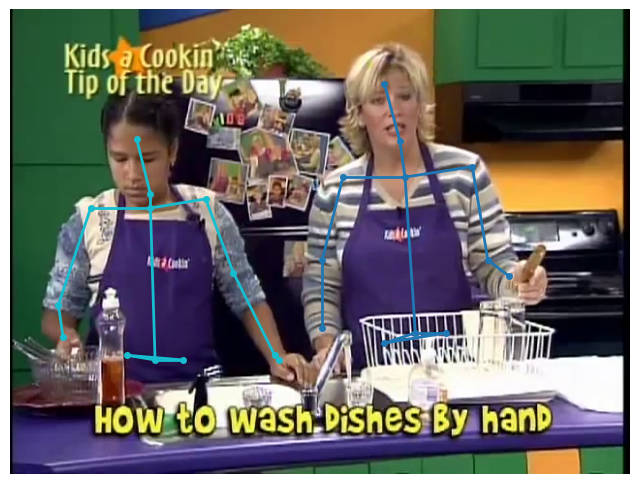

In [15]:
plot_mpii_people(image, mpii_people_keypoints, mpii_people_scores, score_thr=0.2)

### Full dataset analysis (GT + predictions + metrics)

25/750 processed
50/750 processed
75/750 processed
100/750 processed
125/750 processed
150/750 processed
175/750 processed
200/750 processed
225/750 processed
250/750 processed
275/750 processed
300/750 processed
325/750 processed
350/750 processed
375/750 processed
400/750 processed
425/750 processed
450/750 processed
475/750 processed
500/750 processed
525/750 processed
550/750 processed
575/750 processed
600/750 processed
625/750 processed
650/750 processed
675/750 processed
700/750 processed
725/750 processed
750/750 processed

=== Dataset-level summary ===
num_annotations: 750
num_loaded_images: 750
num_matched: 742
image_load_rate: 1.0
detection_rate: 0.9893333333333333
mean_pred_people: 5.0986666666666665
mean_mpjpe_px: 40.58643116205529
median_mpjpe_px: 18.875988006591797
mean_confidence: 0.6961046827108551
runtime_s: 241.6405348777771

=== Per-category MPJPE (px) ===
dancing: 22.155 (n=226)
home activities: 53.444 (n=203)
music playing: 49.260 (n=94)
running: 17.864 (n=75)
wat

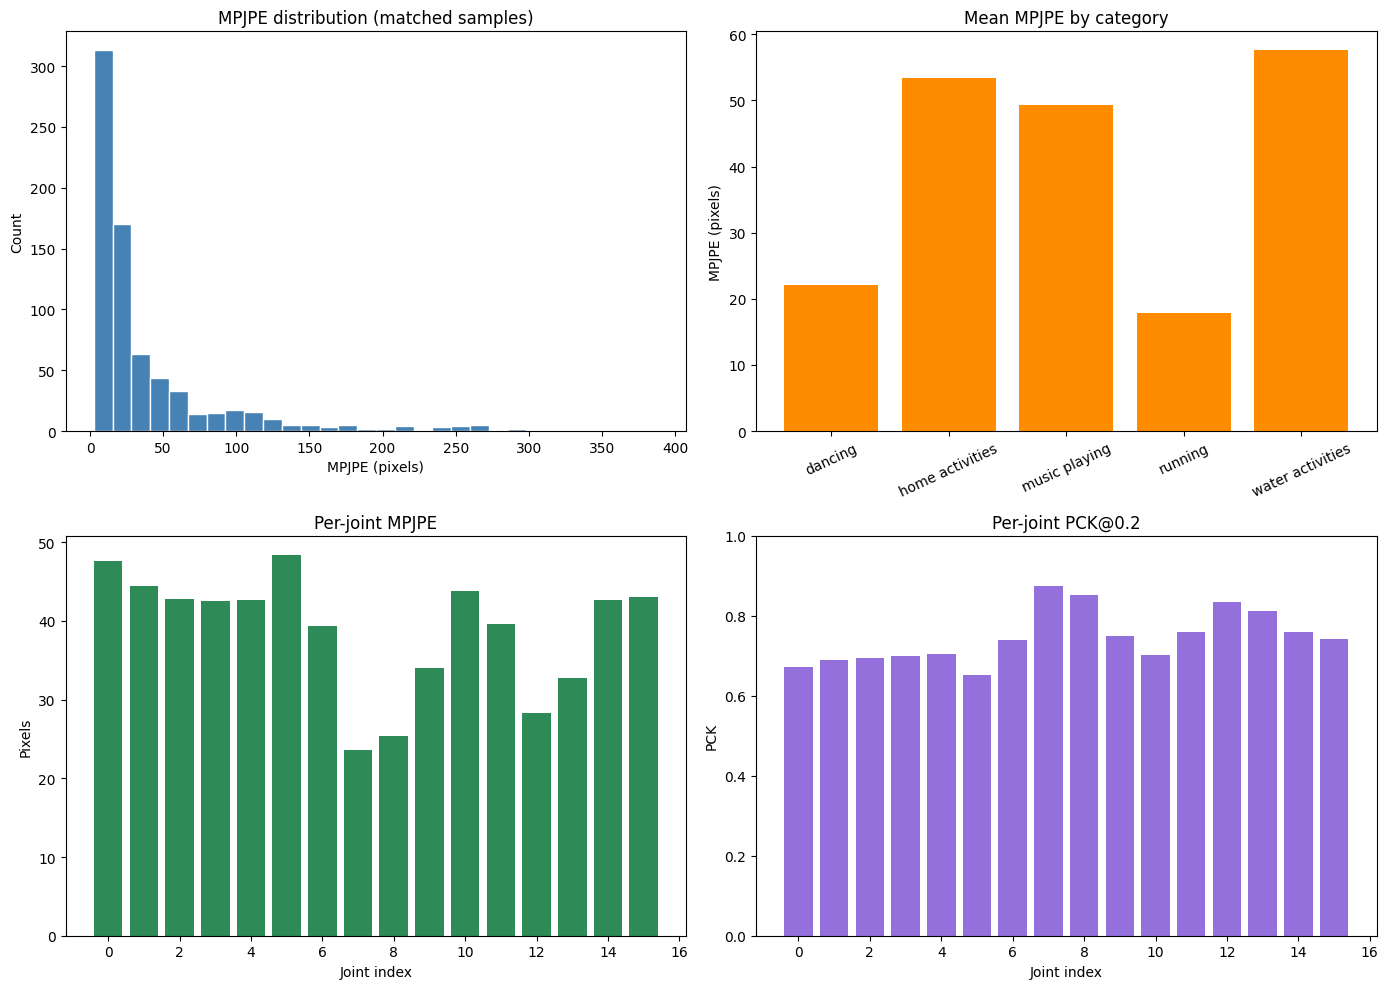

In [16]:
import json
import time
from collections import defaultdict

data_root = "/Users/homefolder/Local/Poly/3-Computer Vision/1-TP/TP3/data"
images_dir = os.path.join(data_root, "images")
annotations_path = os.path.join(data_root, "mpii_val_annotations.json")
pck_alpha = 0.2
max_images = None

with open(annotations_path, "r") as f:
    gt_data = json.load(f)

annotations = gt_data["annotations"]
joint_names = gt_data["joint_names"]
skeleton_edges = [tuple(e) for e in gt_data["skeleton"]]

if max_images is not None:
    annotations = annotations[:max_images]

def predict_all_people(image_bgr, model, device_name="mps"):
    torch.set_default_device(device_name)
    try:
        preds = model.predict(image_bgr)
    finally:
        torch.set_default_device("cpu")
    if preds is None:
        return np.empty((0, 16, 2), dtype=np.float32), np.empty((0, 16), dtype=np.float32)
    preds = np.asarray(preds, dtype=np.float32)
    if len(preds) == 0:
        return np.empty((0, 16, 2), dtype=np.float32), np.empty((0, 16), dtype=np.float32)
    people_xy = preds[:, :, 1::-1]
    people_scores = preds[:, :, 2]
    return people_xy, people_scores

def visible_distances(gt_xy, gt_vis, pred_xy):
    vis_idx = np.where(gt_vis)[0]
    if len(vis_idx) == 0:
        return vis_idx, np.array([], dtype=np.float32)
    d = np.linalg.norm(pred_xy[vis_idx] - gt_xy[vis_idx], axis=1)
    return vis_idx, d

def best_match(gt_xy, gt_vis, people_xy):
    if len(people_xy) == 0:
        return None, np.inf, None, None
    best_i = None
    best_err = np.inf
    best_vis_idx = None
    best_d = None
    for i in range(len(people_xy)):
        vis_idx, d = visible_distances(gt_xy, gt_vis, people_xy[i])
        err = float(d.mean()) if len(d) > 0 else np.inf
        if err < best_err:
            best_i = i
            best_err = err
            best_vis_idx = vis_idx
            best_d = d
    return best_i, best_err, best_vis_idx, best_d

def get_scale(gt_xy, gt_vis):
    if gt_vis[6] and gt_vis[7]:
        return float(np.linalg.norm(gt_xy[6] - gt_xy[7])) + 1e-6
    if gt_vis[8] and gt_vis[9]:
        return float(np.linalg.norm(gt_xy[8] - gt_xy[9])) + 1e-6
    return None

def draw_skeleton(ax, keypoints_xy, edges, color, lw=2, alpha=1.0):
    for a, b in edges:
        ax.plot([keypoints_xy[a, 0], keypoints_xy[b, 0]], [keypoints_xy[a, 1], keypoints_xy[b, 1]], color=color, lw=lw, alpha=alpha)

start = time.time()
records = []
per_joint_sum = np.zeros(len(joint_names), dtype=np.float64)
per_joint_cnt = np.zeros(len(joint_names), dtype=np.int64)
per_joint_pck_hits = np.zeros(len(joint_names), dtype=np.int64)
per_joint_pck_cnt = np.zeros(len(joint_names), dtype=np.int64)

for i, ann in enumerate(annotations):
    image_name = ann["image"]
    category = ann.get("category", "unknown")
    image_path = os.path.join(images_dir, image_name)
    image = cv2.imread(image_path, cv2.IMREAD_COLOR)

    if image is None:
        records.append({
            "image": image_name,
            "category": category,
            "loaded": False,
            "n_pred_people": 0,
            "matched": False,
            "mpjpe_px": np.nan,
            "mean_conf": np.nan,
        })
        continue

    gt_xy = np.asarray(ann["joints"], dtype=np.float32)
    gt_vis = np.asarray(ann["joints_vis"], dtype=bool)

    people_xy, people_scores = predict_all_people(image, model, device_name="mps")
    match_idx, best_err, vis_idx, d = best_match(gt_xy, gt_vis, people_xy)
    matched = match_idx is not None and np.isfinite(best_err)

    if matched:
        matched_scores = people_scores[match_idx]
        mean_conf = float(matched_scores[gt_vis].mean()) if gt_vis.any() else np.nan
        per_joint_sum[vis_idx] += d
        per_joint_cnt[vis_idx] += 1
        scale = get_scale(gt_xy, gt_vis)
        if scale is not None:
            nd = d / scale
            per_joint_pck_hits[vis_idx] += (nd < pck_alpha).astype(np.int64)
            per_joint_pck_cnt[vis_idx] += 1
    else:
        mean_conf = np.nan

    records.append({
        "image": image_name,
        "category": category,
        "loaded": True,
        "n_pred_people": int(len(people_xy)),
        "matched": bool(matched),
        "mpjpe_px": float(best_err) if matched else np.nan,
        "mean_conf": mean_conf,
    })

    if (i + 1) % 25 == 0 or (i + 1) == len(annotations):
        print(f"{i + 1}/{len(annotations)} processed")

elapsed = time.time() - start

loaded_records = [r for r in records if r["loaded"]]
matched_records = [r for r in loaded_records if r["matched"]]

overall = {
    "num_annotations": len(annotations),
    "num_loaded_images": len(loaded_records),
    "num_matched": len(matched_records),
    "image_load_rate": len(loaded_records) / max(len(annotations), 1),
    "detection_rate": len(matched_records) / max(len(loaded_records), 1),
    "mean_pred_people": float(np.mean([r["n_pred_people"] for r in loaded_records])) if loaded_records else np.nan,
    "mean_mpjpe_px": float(np.nanmean([r["mpjpe_px"] for r in matched_records])) if matched_records else np.nan,
    "median_mpjpe_px": float(np.nanmedian([r["mpjpe_px"] for r in matched_records])) if matched_records else np.nan,
    "mean_confidence": float(np.nanmean([r["mean_conf"] for r in matched_records])) if matched_records else np.nan,
    "runtime_s": elapsed,
}

cat_bucket = defaultdict(list)
for r in matched_records:
    cat_bucket[r["category"]].append(r["mpjpe_px"])

category_mpjpe = {k: float(np.mean(v)) for k, v in cat_bucket.items() if len(v) > 0}
category_counts = {k: len(v) for k, v in cat_bucket.items()}

per_joint_mpjpe = np.divide(
    per_joint_sum, per_joint_cnt,
    out=np.full_like(per_joint_sum, np.nan, dtype=np.float64),
    where=per_joint_cnt > 0,
    )
per_joint_pck = np.divide(
    per_joint_pck_hits, per_joint_pck_cnt,
    out=np.full_like(per_joint_sum, np.nan, dtype=np.float64),
    where=per_joint_pck_cnt > 0,
    )

print("\n=== Dataset-level summary ===")
for k, v in overall.items():
    print(f"{k}: {v}")

print("\n=== Per-category MPJPE (px) ===")
for k in sorted(category_mpjpe.keys()):
    print(f"{k}: {category_mpjpe[k]:.3f} (n={category_counts[k]})")

print("\n=== Per-joint MPJPE (px) ===")
for j, name in enumerate(joint_names):
    print(f"{j:02d} {name:>14}: {per_joint_mpjpe[j]:.3f}")

print(f"\n=== Per-joint PCK@{pck_alpha} (torso/head normalized) ===")
for j, name in enumerate(joint_names):
    print(f"{j:02d} {name:>14}: {per_joint_pck[j]:.3f}")

mpjpe_vals = np.array([r["mpjpe_px"] for r in matched_records], dtype=np.float32)
cat_names = sorted(category_mpjpe.keys())

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(mpjpe_vals, bins=30, color="steelblue", edgecolor="white")
axes[0, 0].set_title("MPJPE distribution (matched samples)")
axes[0, 0].set_xlabel("MPJPE (pixels)")
axes[0, 0].set_ylabel("Count")

axes[0, 1].bar(cat_names, [category_mpjpe[c] for c in cat_names], color="darkorange")
axes[0, 1].set_title("Mean MPJPE by category")
axes[0, 1].set_ylabel("MPJPE (pixels)")
axes[0, 1].tick_params(axis="x", rotation=25)

axes[1, 0].bar(range(len(joint_names)), per_joint_mpjpe, color="seagreen")
axes[1, 0].set_title("Per-joint MPJPE")
axes[1, 0].set_xlabel("Joint index")
axes[1, 0].set_ylabel("Pixels")

axes[1, 1].bar(range(len(joint_names)), per_joint_pck, color="mediumpurple")
axes[1, 1].set_title(f"Per-joint PCK@{pck_alpha}")
axes[1, 1].set_xlabel("Joint index")
axes[1, 1].set_ylabel("PCK")
axes[1, 1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

analysis_outputs = {
    "overall": overall,
    "records": records,
    "joint_names": joint_names,
    "skeleton_edges": skeleton_edges,
    "per_joint_mpjpe": per_joint_mpjpe,
    "per_joint_pck": per_joint_pck,
    "category_mpjpe": category_mpjpe,
    "category_counts": category_counts,
}

### quick check of results

In [19]:
print('images:', analysis_outputs['overall']['num_annotations'])
print('matched:', analysis_outputs['overall']['num_matched'])
print('mean mpjpe px:', round(analysis_outputs['overall']['mean_mpjpe_px'], 2))
print('median mpjpe px:', round(analysis_outputs['overall']['median_mpjpe_px'], 2))

print('\nper category mpjpe:')
for cat in analysis_outputs['category_mpjpe']:
    print(cat, '->', round(analysis_outputs['category_mpjpe'][cat], 2), 'px', '(n=', analysis_outputs['category_counts'].get(cat, 0), ')')

print('\nper joint (mpjpe, pck):')
pj_m = analysis_outputs['per_joint_mpjpe']
pj_p = analysis_outputs['per_joint_pck']
for j, name in enumerate(joint_names):
    m = pj_m[j] if j < len(pj_m) else np.nan
    p = pj_p[j] if j < len(pj_p) else np.nan
    if np.isnan(m):
        print(name, '->', 'N/A')
    else:
        p_val = 'N/A' if np.isnan(p) else round(float(p), 3)
        print(name, '->', round(float(m), 2), ',', p_val)

images: 750
matched: 742
mean mpjpe px: 40.59
median mpjpe px: 18.88

per category mpjpe:
dancing -> 22.16 px (n= 226 )
home activities -> 53.44 px (n= 203 )
music playing -> 49.26 px (n= 94 )
running -> 17.86 px (n= 75 )
water activities -> 57.56 px (n= 144 )

per joint (mpjpe, pck):
right_ankle -> 47.59 , 0.673
right_knee -> 44.39 , 0.691
right_hip -> 42.81 , 0.695
left_hip -> 42.51 , 0.699
left_knee -> 42.59 , 0.706
left_ankle -> 48.37 , 0.651
pelvis -> 39.34 , 0.741
thorax -> 23.59 , 0.876
upper_neck -> 25.34 , 0.853
head_top -> 33.98 , 0.75
right_wrist -> 43.78 , 0.703
right_elbow -> 39.56 , 0.761
right_shoulder -> 28.29 , 0.835
left_shoulder -> 32.75 , 0.813
left_elbow -> 42.7 , 0.76
left_wrist -> 43.02 , 0.743
